In [201]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import numba

For the wrapped Gaussian defined on $[-L/2,L/2]$ we have that $$W(r) = - \frac{1}{\sigma \sqrt{2\pi}}\sum^{\infty}_{n=-\infty}\exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) = \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\frac{1}{\sigma \sqrt{2\pi}}\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}-ikr\right)}dr$$
$$ = -\frac{1}{\sigma  \sqrt{2\pi}}\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr $$
$$= -\frac{1}{\sigma  \sqrt{2\pi}}\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\cos{(kr)}dr$$
$$= -\frac{1}{\sigma  \sqrt{2\pi}}\int^{\infty}_{-\infty} \exp{\left(-\frac{r^{2}}{2\sigma^{2}}\right)}\cos{\left(\frac{2\pi z r}{L}\right)}dr$$
$$= -e^{-2\sigma^{2}\pi^{2}z^{2}/L^{2}} = -e^{-\sigma^{2}k^{2}/2}.$$

Alternative: Try non-wrapped Gaussian:
$$
\hat{W}(k)=\int_{-\frac{L}{2}}^{\frac{L}{2}} e^{\frac{r^2}{2\sigma^2}}e^{-ikr}dr=...=-\sqrt{\frac{\pi \sigma^2}{2}}e^{-\frac{k^2\sigma^2}{2}}\left[ erf\left( \frac{\frac{L}{2}-ik\sigma^2}{\sqrt{2\sigma^2}} \right) +erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right] = -\sqrt{2\pi\sigma^2} e^{-\frac{-k^2\sigma^2}{2}}Re\left( erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right)
$$

In [233]:
#Wrapped Gaussian model
σ = 1.0
L = 100.0 #needed for set of frequencies

#@numba.jit(nopython=True)
#def W_hat(k):
#    W_hat_k = -0.5*np.sqrt(2*np.pi)*σ*np.exp(-σ**2 * k**2 /2) #  factor 0.5?
#    W_hat_k = -np.sqrt(2*np.pi)*σ*np.exp(-σ**2 * k**2 /2) #
#    return W_hat_k

# non-wrapped case:
from scipy.special import erf
#@numba.jit(nopython=True)
def W_hat(k):
    W_hat_k = -np.sqrt(2*np.pi)*σ * np.exp(-σ**2*k**2/2)*np.real( erf( (0.5*L + 1j*k*σ**2)/(np.sqrt(2*σ**2)) ) )
    return W_hat_k
    
#@numba.jit(nopython=True)
def matrix(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat(k)/L 
    return A_k

In [225]:
ks = np.arange(0,20)*2*np.pi/L
for k in ks:
    print(np.max(np.real(np.linalg.eigvals(matrix(k, 3, 0.1, L, 30)))))

-0.0
-0.12025794842635998
-0.5199398727586564
-0.919462616031347
-0.9557858040013723
-0.9640210242105327
-0.9659503251993637
-0.9665861920994119
-0.9669289658052258
-0.9671576297810506
-0.9673208665431097
-0.96744143632782
-0.9675332081506027
-0.9676045056477466
-0.9676611508705141
-0.9677067603829134
-0.9677441533940876
-0.9677750746555785
-0.9678010426967011
-0.9678229636224318


In [210]:
np.max(np.real(np.linalg.eigvals(matrix(1, 5., 0.1, 20, 200))))

-0.2832998054796126

In [235]:
#3d plot of β vs γ vs spectral gap
#@numba.jit(nopython=True)
def function():
    N_β = 200
    N_γ = 3
    β_list = np.linspace(30,45,N_β)
    γ_list = np.linspace(0.0,1,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    spectral_radius = np.zeros((N_β,N_γ))
    k_max = 50
    approximation_dimension = 40
    for i in range(len(β_list)):
        print(i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = np.max(np.real(np.linalg.eigvals(matrix(0.,β,γ,L,approximation_dimension))))
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
                partial_max = np.max(np.real(np.linalg.eigvals(matrix(-2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    return β_list,γ_list,spectral_radius


# $(2\pi)^{1/2} * \sigma \frac{N}{2L} \kappa$ in 1D

In [236]:
β_list,γ_list,spectral_radius = function()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199


In [219]:
spectral_radius[:,-1]


array([3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3.44980105e+103, 3.44980105e+103, 3.44980105e+103,
       3.44980105e+103, 3

In [229]:
β_list

array([ 0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,
        1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,
        2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,  3.3,
        3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,  4.4,
        4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,  5.5,
        5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,  6.6,
        6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,  7.7,
        7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,  8.8,
        8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,  9.9,
       10. ])

Text(0, 0.5, 'Theoretical Cluster Time for 1000 particles')

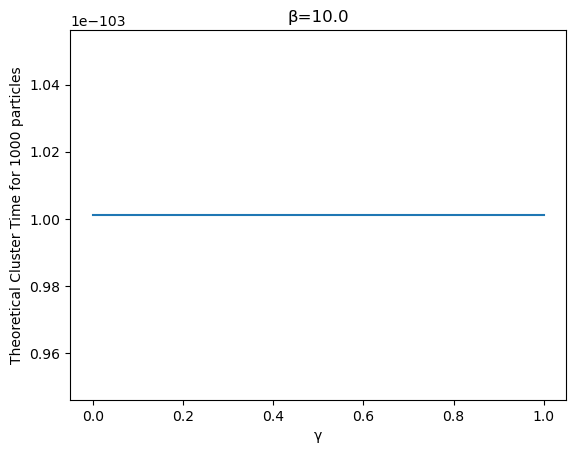

In [218]:
plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

In [234]:
print('Theoretical critcal beta = ',1/((σ**2)*np.sqrt(2*np.pi)/(L)))

Theoretical critcal beta =  39.894228040143275


Crit. Beta:  40.0251256281407


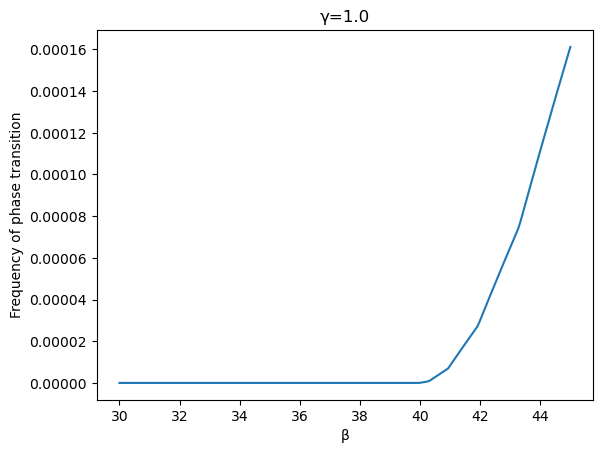

In [238]:
gamma_idx = 2
plt.plot(β_list,spectral_radius[:,gamma_idx])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[gamma_idx]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')

print("Crit. Beta: ", β_list[ np.argmax(spectral_radius[:,gamma_idx]>0) ] )

In [10]:
print(np.max(spectral_radius))
print(1/((σ**2)*np.pi/(L**2)))

0.271654302213204
7.957747154594767


In [11]:
spectral_radius[spectral_radius > 0]

array([9.54969436e-12, 6.80367221e-13, 3.83693079e-13, ...,
       1.29463785e-02, 1.28147573e-02, 1.26857807e-02])

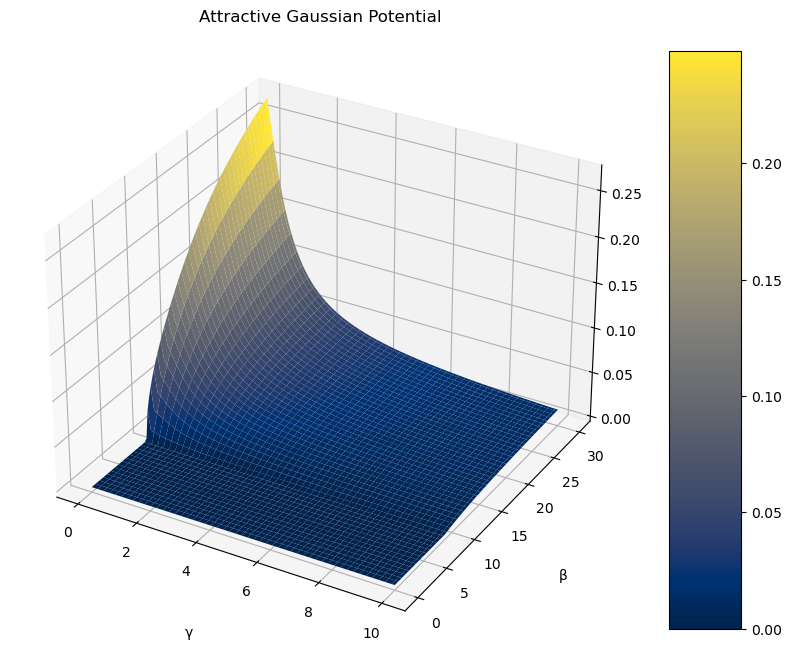

In [12]:
#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Attractive Gaussian Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()

# Von Mises-Fisher

For the Von Mises-Fisher potential defined on $[-L/2,L/2]$ we have that $$W(r) = - I_{0}(\kappa)^{-2}\exp{\left\{\theta\cos(2\pi x/L)\right\}}$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) = \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)-ikr\right)}dr$$
$$ = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr $$
$$ = -\frac{1}{I_{0}(\kappa)^{2}}\int^{L/2}_{-L/2} \exp{\left(\theta\cos(2\pi r/L)\right)}\cos{(\frac{2\pi z r}{L})}dr. $$

In [13]:
from scipy.special import jv
from scipy.integrate import quad

θ = 1.
κ = 1

#@numba.jit(nopython=True)
def integrand(r,z):
    #integrate numerically
    des = -np.exp(θ*np.cos(2*np.pi*r/L))*np.cos(z*r)/jv(0, κ)**2
    return des 


def W_hat_VMF(k):
    #integrate numerically
    W_hat_k = quad(integrand,-L/2,L/2,args = (k))
    return W_hat_k[0]


def matrix_VMF(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat_VMF(k)/L
    return A_k

In [14]:
print(np.max(np.real(np.linalg.eigvals(matrix_VMF(1,1,1.,10,20)))))
print(np.max(np.real(np.linalg.eigvals(matrix_VMF(1,10,1.,10,20)))))

-0.22835166613319002
0.3760422870660214


In [15]:
def function_VMF():
    N_β = 30
    N_γ = 100
    β_list = np.linspace(0.001,30,N_β)
    γ_list = np.linspace(0.0,10,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    spectral_radius = np.zeros((N_β,N_γ))
    k_max = 10
    approximation_dimension = 15
    for i in range(len(β_list)):
        print(i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = np.max(np.real(np.linalg.eigvals(matrix_VMF(0.,β,γ,L,approximation_dimension))))
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix_VMF(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    return β_list,γ_list,spectral_radius

In [16]:
# β_list,γ_list,spectral_radius = function_VMF()

# plt.plot(γ_list,np.log(1000)/2*spectral_radius[0,:])
# plt.show()
# #plt.xscale('log')

# print(spectral_radius)

Text(0, 0.5, 'Theoretical Cluster Time for 1000 particles')

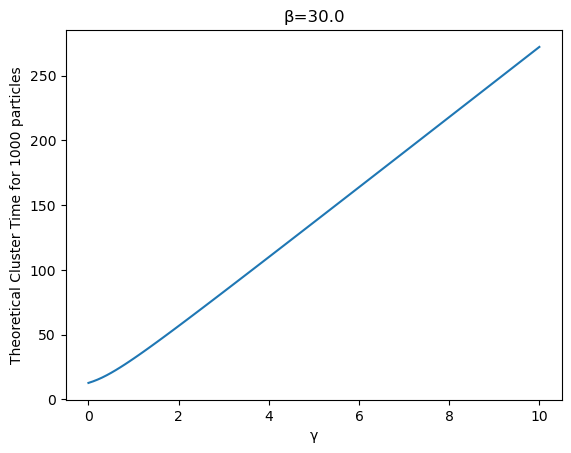

In [17]:
plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
#plt.xscale('log')
#plt.yscale('log')
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

Text(0, 0.5, 'Frequency of phase transition')

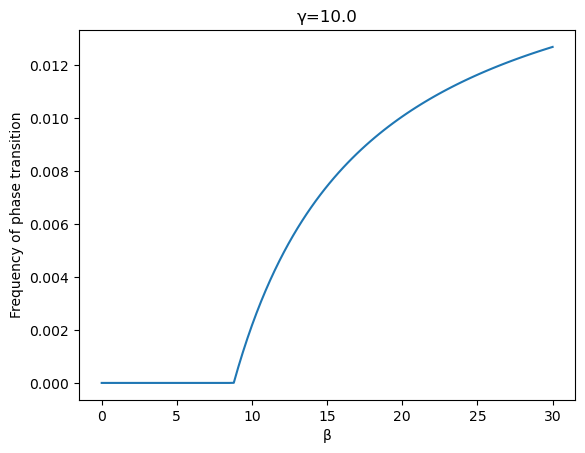

In [18]:
plt.plot(β_list,spectral_radius[:,-1])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[-1]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')

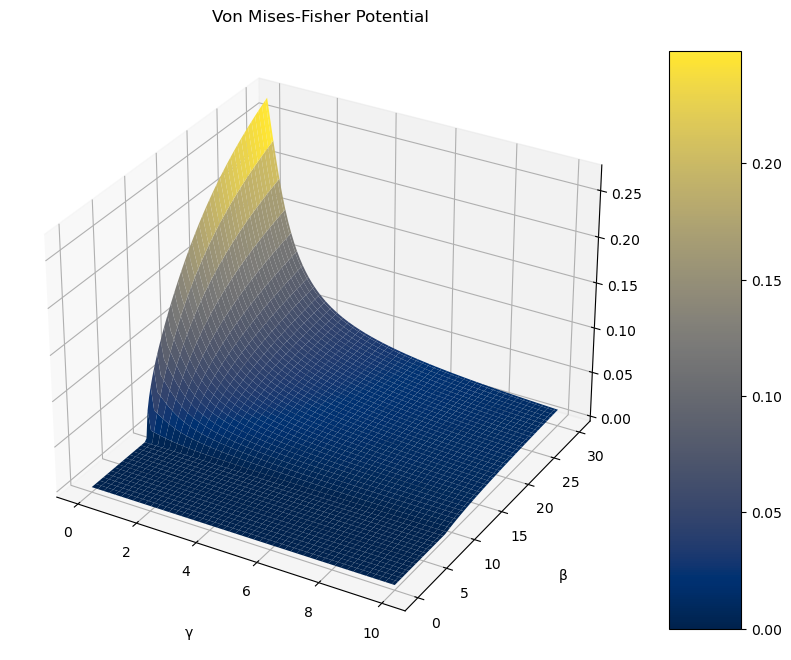

In [19]:
#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Von Mises-Fisher Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()

# Morse potential

For the Morse potential defined on $[-L/2,L/2]$ we have that $$W(r) = \lambda^{2}(e^{-2|r|}-e^{-|r|})$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) = \int^{L/2}_{-L/2} W(r) e^{-ik r}dr =  \lambda^{2}\int^{L/2}_{-L/2}(e^{-2|r| - ikr}-e^{-|r| - ikr})dr$$
$$ = \lambda^{2}\int^{L/2}_{-L/2} (e^{-2|r|}-e^{-|r|})\left(\cos{(kr)} - i\sin{(kr)}\right)dr $$
$$ =  \lambda^{2}\int^{L/2}_{-L/2} (e^{-2|r|}-e^{-|r|})\cos{(2\pi zr/L)}dr . $$

In [20]:
# to do
λ = 1.

#@numba.jit(nopython=True)
def integrand_MORSE(r,z):
    #integrate numerically
    des = (λ**2)*(np.exp(-2*np.abs(r))-np.exp(-np.abs(r)))*np.cos(z*r)/jv(0, κ)**2
    return des 


def W_hat_MORSE(k):
    #integrate numerically
    W_hat_k = quad(integrand_MORSE,-L/2,L/2,args = (k))
    return W_hat_k[0]


def matrix_MORSE(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat_MORSE(k)/L
    return A_k

In [21]:
print(np.max(np.real(np.linalg.eigvals(matrix_MORSE(1,1,1.,L,15)))))
print(np.max(np.real(np.linalg.eigvals(matrix_MORSE(1,100,10.,L,15)))))

-0.7835218844358919
0.009543022363009798


In [22]:
def function_MORSE():
    N_β = 100
    N_γ = 100
    β_list = np.linspace(0.001,100,N_β)
    γ_list = np.linspace(0.0,10,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    spectral_radius = np.zeros((N_β,N_γ))
    k_max = 20
    approximation_dimension = 20
    for i in range(len(β_list)):
        print(i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = np.max(np.real(np.linalg.eigvals(matrix_MORSE(0.,β,γ,L,approximation_dimension))))
            for k in range(k_max - 1):
                #change to maximum real part
                partial_max = np.max(np.real(np.linalg.eigvals(matrix_MORSE(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
                #print(partial_max,maximum)
                if partial_max > maximum:
                    maximum = partial_max
            spectral_radius[i,j] = maximum
    return β_list,γ_list,spectral_radius

In [23]:
β_list,γ_list,spectral_radius = function_MORSE()

# plt.plot(γ_list,np.log(1000)/2*spectral_radius[0,:])
# plt.show()
# #plt.xscale('log')

# print(spectral_radius)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [24]:
spectral_radius[-1,:]

array([0.17301592, 0.14784116, 0.12480877, 0.1054692 , 0.08996824,
       0.07771815, 0.0680094 , 0.06023348, 0.05392194, 0.04872761,
       0.04439558, 0.04073802, 0.03761519, 0.03492185, 0.03257775,
       0.03052086, 0.02870265, 0.02708469, 0.02563623, 0.02433239,
       0.02315286, 0.02208092, 0.02110265, 0.02020644, 0.01938249,
       0.01862247, 0.01791929, 0.01726685, 0.0166599 , 0.01609387,
       0.01556479, 0.01506917, 0.01460396, 0.01416645, 0.01375426,
       0.01336527, 0.01299757, 0.01264947, 0.01231945, 0.01200615,
       0.01170832, 0.01142487, 0.01115476, 0.0108971 , 0.01065103,
       0.01041579, 0.01019069, 0.00997509, 0.0097684 , 0.00957008,
       0.00937963, 0.00919659, 0.00902055, 0.0088511 , 0.00868789,
       0.00853058, 0.00837886, 0.00823242, 0.00809101, 0.00795436,
       0.00782225, 0.00769444, 0.00757074, 0.00745095, 0.00733488,
       0.00722237, 0.00711325, 0.00700738, 0.00690461, 0.0068048 ,
       0.00670784, 0.00661359, 0.00652196, 0.00643283, 0.00634

Text(0, 0.5, 'Theoretical Cluster Time for 1000 particles')

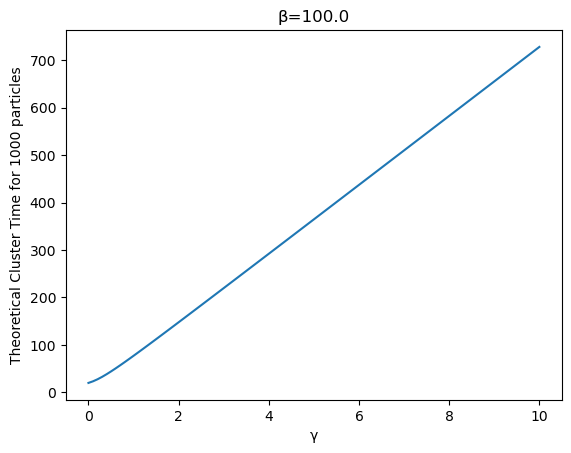

In [25]:
plt.plot(γ_list,np.log(1000)/(2*spectral_radius[-1,:]))
#plt.xscale('log')
#plt.yscale('log')
plt.title('β='+str(β_list[-1]))
plt.xlabel('γ')
plt.ylabel('Theoretical Cluster Time for 1000 particles')

Text(0, 0.5, 'Frequency of phase transition')

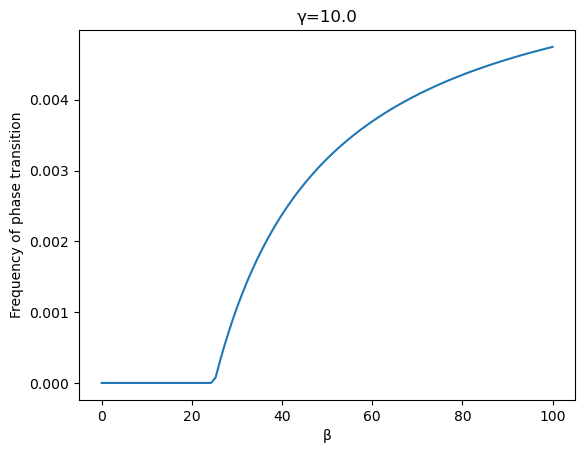

In [26]:
plt.plot(β_list,spectral_radius[:,-1])
#plt.xscale('log')
#plt.yscale('log')
plt.title('γ='+str(γ_list[-1]))
plt.xlabel('β')
plt.ylabel('Frequency of phase transition')

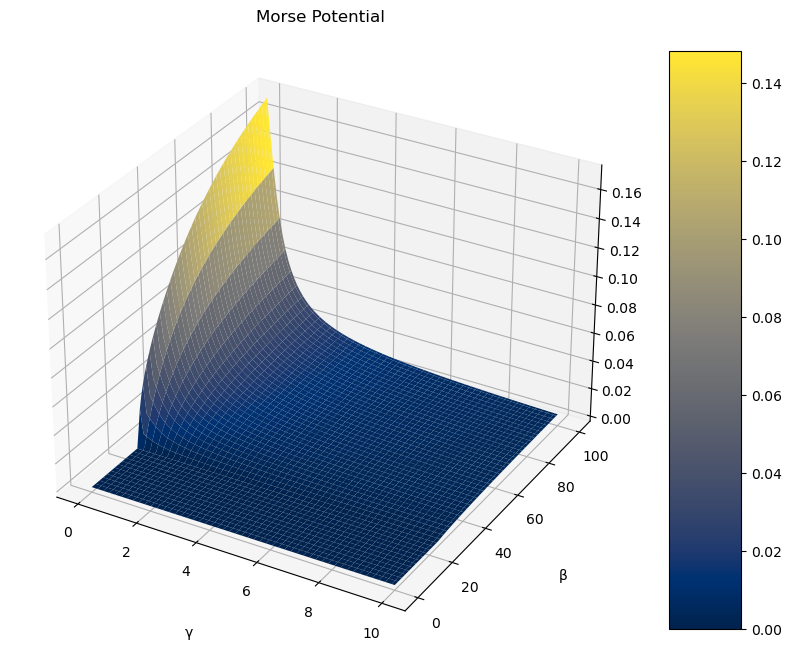

In [27]:
#zlim = 0.1
fig = plt.figure(figsize =(10,15))
ax = plt.axes(projection ='3d')

X, Y = np.meshgrid(γ_list,β_list)

# Creating plot
surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)



# Set axes label
ax.set_xlabel('γ', labelpad=20)
ax.set_ylabel('β', labelpad=20)
ax.set_zlabel('$k_{max}$', labelpad=20)
#ax.axes.set_zlim3d(bottom=0, top=zlim)
ax.set_title('Morse Potential')

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()